# 09_SHAP_Explainability.ipynb
## FakeJobShield: Explainable AI with SHAP
This notebook loads the trained XGBoost model and applies SHAP (SHapley Additive exPlanations) to explain predictions globally and locally. It outputs summary plots, feature importances, waterfalls, and local force plots explaining why specific jobs are flagged as fraudulent.


In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
import os

# Adjust working directory if run from notebooks folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sns.set_theme(style="whitegrid")


C:\Users\Rudra\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load best tuned XGBoost model
best_xgb = joblib.load("models/best_xgboost.pkl")

# Load feature pipeline & cleaned dataset
feature_pipeline = joblib.load("models/feature_pipeline.pkl")
df = pd.read_csv("data/cleaned_fake_job_postings.csv")
df["fraudulent_int"] = df["fraudulent"].map({'t': 1, 'f': 0, '1': 1, '0': 0, 1: 1, 0: 0}).fillna(0).astype(int)
y = df["fraudulent_int"].values

# Extract features
vectorizer = feature_pipeline["vectorizer"]
label_encoders = feature_pipeline["label_encoders"]

x_tfidf = vectorizer.transform(df["cleaned_text"].fillna(""))
for col in ["telecommuting", "has_company_logo", "has_questions"]:
    df[col] = df[col].map({'t': 1, 'f': 0, '1': 1, '0': 0, 1: 1, 0: 0, True: 1, False: 0}).fillna(0).astype(int)
x_binary = df[["telecommuting", "has_company_logo", "has_questions"]].values

encoded_cats = []
for col in ["employment_type", "required_experience", "required_education", "industry", "function"]:
    df[col] = df[col].fillna("missing").astype(str)
    le = label_encoders[col]
    df[col + "_encoded"] = le.transform(df[col])
    encoded_cats.append(df[col + "_encoded"].values.reshape(-1, 1))
x_categorical = np.hstack(encoded_cats)

x_final = hstack([x_tfidf, csr_matrix(x_binary), csr_matrix(x_categorical)]).tocsr()


In [3]:
# Fit SHAP Explainer
bg_data = x_final[np.random.choice(x_final.shape[0], 100, replace=False)].toarray()
test_data = x_final[np.random.choice(x_final.shape[0], 100, replace=False)].toarray()

feature_names = (
    list(vectorizer.get_feature_names_out()) + 
    ["telecommuting", "has_company_logo", "has_questions"] + 
    ["employment_type", "required_experience", "required_education", "industry", "function"]
)

explainer = shap.TreeExplainer(best_xgb, bg_data)
shap_values = explainer(test_data)
print("SHAP Values computed successfully!")


SHAP Values computed successfully!


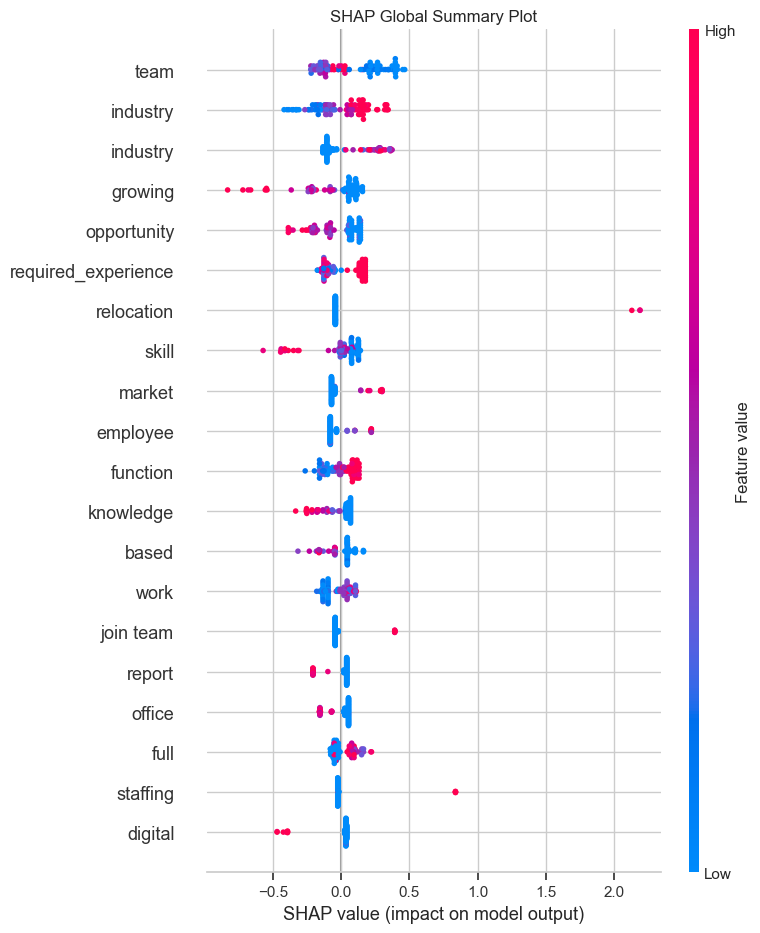

In [4]:
# 1. Global Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_data, feature_names=feature_names, show=False)
plt.title("SHAP Global Summary Plot")
plt.tight_layout()
plt.savefig("results/shap_summary_plot.png", dpi=150)
plt.show()


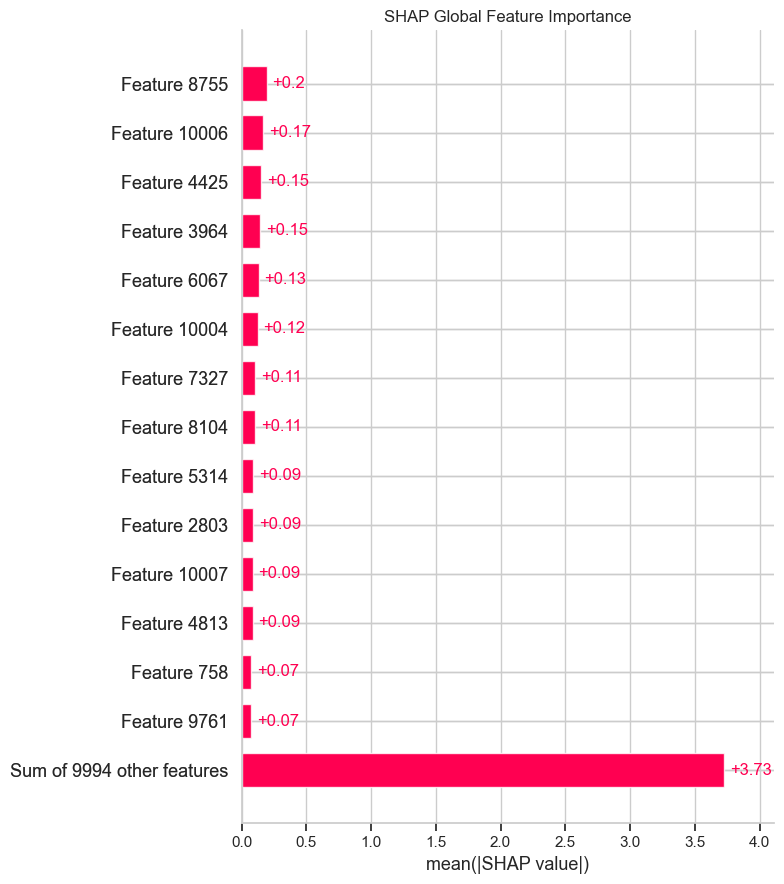

In [5]:
# 2. Global Feature Importance Plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig("results/shap_feature_importance.png", dpi=150)
plt.show()


Explaining test sample index 99 with fraud probability: 0.1646


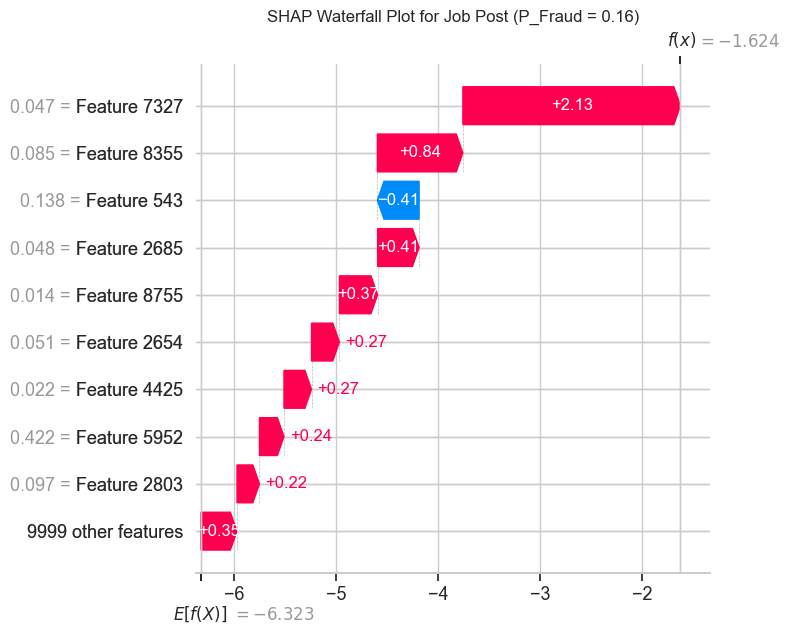

In [6]:
# 3. Local Explanation (Waterfall Plot)
probs = best_xgb.predict_proba(test_data)[:, 1]
high_fraud_idx = np.argmax(probs)
print(f"Explaining test sample index {high_fraud_idx} with fraud probability: {probs[high_fraud_idx]:.4f}")

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[high_fraud_idx], max_display=10, show=False)
plt.title(f"SHAP Waterfall Plot for Job Post (P_Fraud = {probs[high_fraud_idx]:.2f})")
plt.tight_layout()
plt.savefig("results/shap_local_waterfall.png", dpi=150)
plt.show()


<Figure size 1200x400 with 0 Axes>

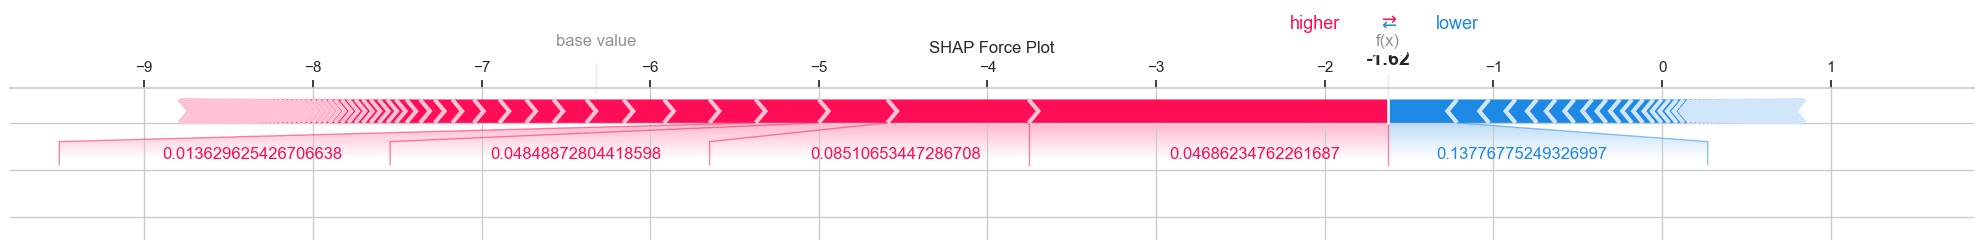

In [7]:
# 4. Local Explanation (Force Plot)
plt.figure(figsize=(12, 4))
shap.plots.force(shap_values[high_fraud_idx], matplotlib=True, show=False)
plt.title("SHAP Force Plot")
plt.tight_layout()
plt.savefig("results/shap_local_force_plot.png", dpi=150)
plt.show()
